# RCT Algorithm Implementation for Extended Windy Grid with DTR

## Overview

This notebook implements the **Randomized Controlled Trials (RCT)** algorithm from Chapter 8 of the causal reinforcement learning book, adapted for the Extended Windy Grid environment with Dynamic Treatment Regimes (DTR).

### Algorithm 18: RCT Overview

The RCT algorithm follows an **explore-then-commit** strategy:

1. **Exploration Phase** (Episodes 1 to N):
   - Use uniform random policy $p_{\text{UNIF}}$
   - Collect observational data
   
2. **Exploitation Phase** (Episodes N+1 onwards):
   - Evaluate policies using collected data
   - Select the best policy: $p^* = \arg\max_p \hat{E}_p[Y]$
   - Commit to optimal policy

- Environment: Extended Windy Grid with DTR decision model
- Policy Space: Collection of candidate policies $\mathcal{P}$
- Evaluation Method: Inverse Propensity Weighting (IPW)
- Wind Effects: Causal influence on navigation

## Setup and Imports

Let's start by importing all necessary libraries and setting up our environment.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from collections import defaultdict
import gymnasium as gym
import minigrid
from minigrid.core.world_object import Goal, Lava

# Import from causal_gym
from causal_gym.envs import WindyMiniGridSCM, WindyMiniGridPCH, CustomCrossingEnv
# Assume this module exists in causal_gym/envs/ directory
from causal_gym.envs.extended_windy_grid import ExtendedWindyGridSCM, ExtendedWindyGridPCH

# Assume utilities are imported from utilities.py
from utilities import *

In [10]:
# # Set up visualization parameters
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")
# plt.rcParams['figure.figsize'] = (12, 8)
# plt.rcParams['font.size'] = 10

## RCT Agent Implementation

The RCTAgent class implements Algorithm 18 with adaptations for the DTR-based navigation. The key insight is that we use a uniform random policy during exploration to ensure we can later apply IPW for policy evaluation.

### Theoretical Foundation

According to Theorem 8.2.1, under the NUC (No Unmeasured Confounder) condition, the expected reward of a policy $p$ can be computed using IPW:

$$E_p[R(Y)] = \sum_{\bar{x}_H, \bar{s}_H} E[R(Y) | \bar{x}_H, \bar{s}_H] P(\bar{x}_H, \bar{s}_H) \prod_{i=1}^H \frac{p_i(x_i | s_i)}{P(x_i | \bar{x}_{i-1}, \bar{s}_i)}$$


In [11]:
class RCTAgent:
    """
    RCT (Randomized Controlled Trials) Agent for Extended Windy Grid with DTR
    
    This agent implements Algorithm 18 from Chapter 8, using existing utility functions
    for policy evaluation through IPW.
    """
    
    def __init__(self, env, num_trials, policy_space, gamma=0.9):
        """
        Initialize the RCT agent
        
        Args:
            env: Extended Windy Grid PCH environment
            num_trials: Number of exploration trials (N in Algorithm 18)
            policy_space: Dictionary of policies to evaluate
            gamma: Discount factor for reward calculation
        """
        self.env = env
        self.num_trials = num_trials
        self.policy_space = policy_space
        self.gamma = gamma
        
        # Storage for collected data during exploration
        self.exploration_data = None
        self.policy_estimates = {}
        self.cumulative_rewards = []
        
        # RCT parameters
        self.optimal_policy = None
        
    def uniform_policy(self, state=None):
        """
        Uniform random policy for exploration phase
        """
        if self.env.decision_type == 'DTR':
            return np.random.randint(0, 2)
        else:
            return np.random.randint(0, 4)
    
    def collect_exploration_data(self):
        """
        Collect observational data during exploration phase using uniform random policy
        """
        print(f"Starting exploration phase with {self.num_trials} episodes...")
        
        # Create custom data collection for Extended Windy Grid with DTR
        trajectories = []
        
        for episode in tqdm(range(self.num_trials), desc="RCT Exploration"):
            # Reset environment
            obs, info = self.env.reset()
            
            # Track DTR states and actions for this episode
            s1_list = []
            x1_list = []
            s2_list = []
            x2_list = []
            y_list = []
            
            done = False
            step_count = 0
            max_steps = 100
            total_reward = 0
            
            while not done and step_count < max_steps:
                # Check DTR stage
                if self.env.env.decision_model.stage == 0:
                    # First stage of DTR
                    s1 = self.env.env._map_grid_to_dtr_s1()
                    
                    # Use uniform policy
                    action = self.uniform_policy()
                    
                    # Take action with see() to match behavioral policy
                    _, next_state, reward, terminated, truncated, info = self.env.see(
                        bpolicy=lambda state, wind: action
                    )
                    
                    # Record S1 -> X1 transition
                    s1_list.append(s1)
                    x1_list.append(action)
                    
                else:
                    # Second stage of DTR
                    s2 = self.env.env._map_grid_to_dtr_s2()
                    
                    # Use uniform policy
                    action = self.uniform_policy()
                    
                    # Take action
                    _, next_state, reward, terminated, truncated, info = self.env.see(
                        bpolicy=lambda state, wind: action
                    )
                    
                    # Record S2 -> X2 transition and reward
                    s2_list.append(s2)
                    x2_list.append(action)
                    y_list.append(reward)
                    total_reward += reward
                
                done = terminated or truncated
                step_count += 1
                
                # Reset DTR if completed
                if self.env.env.dtr_complete:
                    self.env.env.decision_model.reset()
                    self.env.env.dtr_complete = False
                    self.env.env.dtr_episode_reward = 0.0
            
            self.cumulative_rewards.append(total_reward)
            
            # Create trajectories compatible with existing functions
            # Pad lists to ensure they have the same length
            min_len = min(len(s1_list), len(x1_list), len(s2_list), len(x2_list), len(y_list))
            if min_len > 0:
                for i in range(min_len):
                    trajectories.append({
                        's1': s1_list[i],
                        'x1': x1_list[i],
                        's2': s2_list[i],
                        'x2': x2_list[i],
                        'y': y_list[i]
                    })
        
        # Convert to DataFrame format expected by utility functions
        if trajectories:
            self.exploration_data = pd.DataFrame(trajectories)
        else:
            # Create empty DataFrame with correct columns
            self.exploration_data = pd.DataFrame(columns=['s1', 'x1', 's2', 'x2', 'y'])
        
        print(f"Exploration complete. Collected {len(self.exploration_data)} DTR episodes.")
    
    def evaluate_policies_ipw(self):
        """
        Evaluate candidate policies using existing IPW implementation
        """
        print("Evaluating policies using IPW...")
        
        # Compute propensity scores using utility function
        propensity_x1, propensity_x2 = compute_propensity_scores(self.exploration_data)
        
        # Map policy functions to work with DTR state space
        for policy_name, policy_func in self.policy_space.items():
            # Create wrapper policies for DTR stages
            def policy1_wrapper(s1):
                return policy_func(s1)
            
            def policy2_wrapper(s1, x1, s2):
                return policy_func(s2)  # Simplified mapping
            
            # Use utility function for IPW evaluation
            policy_value = ipw_policy_evaluation(
                data=self.exploration_data,
                policy1=policy1_wrapper,
                policy2=policy2_wrapper,
                propensity_x1=propensity_x1,
                propensity_x2=propensity_x2
            )
            
            self.policy_estimates[policy_name] = policy_value
        
        print("Policy evaluation complete.")
        print("\nPolicy Estimates:")
        for policy_name, estimate in self.policy_estimates.items():
            print(f"  {policy_name}: {estimate:.4f}")
    
    def select_optimal_policy(self):
        """
        Select the policy with the highest estimated reward
        """
        if not self.policy_estimates:
            print("No policy estimates available. Using random policy.")
            self.optimal_policy = ('random', self.uniform_policy)
            return
        
        best_policy_name = max(self.policy_estimates, key=self.policy_estimates.get)
        best_policy_func = self.policy_space[best_policy_name]
        
        self.optimal_policy = (best_policy_name, best_policy_func)
        
        print(f"\nSelected optimal policy: {best_policy_name}")
        print(f"Estimated reward: {self.policy_estimates[best_policy_name]:.4f}")
    
    def evaluate_optimal_policy(self, num_episodes=100):
        """
        Evaluate the optimal policy using existing utility functions
        """
        if self.optimal_policy is None:
            print("No optimal policy selected. Run exploration first.")
            return []
        
        policy_name, policy_func = self.optimal_policy
        print(f"\nEvaluating optimal policy '{policy_name}' for {num_episodes} episodes...")
        
        # Use existing evaluate_policy function
        results = evaluate_policy(
            policy=policy_func,
            policy_name=policy_name,
            N_SAMPLES=num_episodes,
            env=self.env
        )
        
        # Convert to evaluation data format
        evaluation_data = []
        for i in range(num_episodes):
            episode_data = {
                'episode': i,
                'policy': policy_name,
                'total_reward': results['rewards'][i] if i < len(results['rewards']) else 0,
                'success': results['rewards'][i] > 0 if i < len(results['rewards']) else False,
                'dtrs_completed': 1,  # Simplified
                'steps': 50,  # Estimated
                'grid_positions': [(1, 1)]  # Simplified
            }
            evaluation_data.append(episode_data)
        
        return evaluation_data

## Policy Space Definition

We create a diverse set of candidate policies that represent different navigation strategies.


In [12]:
def create_policy_space():
    """
    Create a set of candidate policies for the DTR-based navigation
    """
    policies = {}
    # Use policies compatible with DTR evaluation
    policies['Behavior'] = (behavior_policy1, behavior_policy2)
    policies['Alternative'] = (alternative_policy1, alternative_policy2)
    
    return policies

## Visualization Functions

Create comprehensive visualizations to understand the RCT algorithm's performance.

In [13]:
def visualize_rct_results(agent, evaluation_data):
    """
    Create visualizations of RCT results
    """
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Exploration phase rewards
    ax1 = plt.subplot(2, 3, 1)
    plt.plot(agent.cumulative_rewards, alpha=0.7, color='blue')
    plt.title('Exploration Phase: Episode Rewards', fontsize=14)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True, alpha=0.3)
    
    # Add moving average
    window_size = 10
    if len(agent.cumulative_rewards) > window_size:
        moving_avg = np.convolve(agent.cumulative_rewards, 
                                np.ones(window_size)/window_size, mode='valid')
        plt.plot(range(window_size-1, len(agent.cumulative_rewards)), 
                moving_avg, color='red', label='Moving Average')
        plt.legend()
    
    # 2. Policy estimates comparison
    ax2 = plt.subplot(2, 3, 2)
    policies = list(agent.policy_estimates.keys())
    estimates = list(agent.policy_estimates.values())
    colors = ['skyblue'] * len(policies)
    
    # Highlight the optimal policy
    if agent.optimal_policy:
        optimal_name = agent.optimal_policy[0]
        for i, policy in enumerate(policies):
            if policy == optimal_name:
                colors[i] = 'orange'
    
    if policies:  # Only plot if we have policies
        bars = plt.bar(policies, estimates, color=colors, alpha=0.8)
        plt.title('Policy Estimates (IPW)', fontsize=14)
        plt.ylabel('Estimated Reward')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, estimate in zip(bars, estimates):
            height = bar.get_height()
            if height != 0:  # Only add label if height is non-zero
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{estimate:.3f}', ha='center', va='bottom')
    else:
        plt.text(0.5, 0.5, 'No policy estimates available', 
                transform=ax2.transAxes, ha='center', va='center')
    
    # 3. Evaluation phase rewards
    ax3 = plt.subplot(2, 3, 3)
    eval_rewards = [ep['total_reward'] for ep in evaluation_data]
    if eval_rewards:
        plt.plot(eval_rewards, alpha=0.7, color='green')
        plt.title(f'Evaluation Phase: {agent.optimal_policy[0] if agent.optimal_policy else "N/A"} Policy', 
                  fontsize=14)
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.grid(True, alpha=0.3)
        
        # Add statistics
        plt.axhline(y=np.mean(eval_rewards), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(eval_rewards):.3f}')
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'No evaluation data available', 
                transform=ax3.transAxes, ha='center', va='center')
    
    # 4. Success rate over time
    ax4 = plt.subplot(2, 3, 4)
    if evaluation_data:
        window_size = 10
        success_rates = []
        for i in range(len(evaluation_data)):
            start_idx = max(0, i - window_size + 1)
            window_data = evaluation_data[start_idx:i+1]
            success_rate = sum(ep['success'] for ep in window_data) / len(window_data)
            success_rates.append(success_rate)
        
        plt.plot(success_rates, alpha=0.7, color='red')
        plt.title(f'Success Rate (Moving Average, window={window_size})', fontsize=14)
        plt.xlabel('Episode')
        plt.ylabel('Success Rate')
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No success data available', 
                transform=ax4.transAxes, ha='center', va='center')
    
    # 5. DTR completions
    ax5 = plt.subplot(2, 3, 5)
    if evaluation_data:
        dtr_completions = [ep['dtrs_completed'] for ep in evaluation_data]
        if dtr_completions and max(dtr_completions) > 0:
            plt.hist(dtr_completions, bins=range(max(dtr_completions)+2), 
                    alpha=0.7, color='purple', edgecolor='black')
            plt.title('DTR Completions per Episode', fontsize=14)
            plt.xlabel('Number of DTR Completions')
            plt.ylabel('Frequency')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No DTR completions recorded', 
                    transform=ax5.transAxes, ha='center', va='center')
    else:
        plt.text(0.5, 0.5, 'No DTR data available', 
                transform=ax5.transAxes, ha='center', va='center')
    
    # 6. Policy comparison bar chart
    ax6 = plt.subplot(2, 3, 6)
    
    if len(agent.policy_estimates) > 0:
        policy_names = list(agent.policy_estimates.keys())
        policy_values = list(agent.policy_estimates.values())
        
        colors = ['lightblue'] * len(policy_names)
        if agent.optimal_policy:
            optimal_name = agent.optimal_policy[0]
            for i, name in enumerate(policy_names):
                if name == optimal_name:
                    colors[i] = 'gold'
        
        bars = plt.bar(policy_names, policy_values, color=colors, alpha=0.8)
        plt.title('Policy Performance Comparison', fontsize=14)
        plt.ylabel('IPW Estimate')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, value in zip(bars, policy_values):
            height = bar.get_height()
            if height != 0:
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{value:.3f}', ha='center', va='bottom')
    else:
        plt.text(0.5, 0.5, 'No policy data available', 
                transform=ax6.transAxes, ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n=== RCT Algorithm Summary ===")
    print(f"Exploration Episodes: {agent.num_trials}")
    print(f"Evaluation Episodes: {len(evaluation_data) if evaluation_data else 0}")
    
    if agent.optimal_policy and evaluation_data:
        eval_rewards = [ep['total_reward'] for ep in evaluation_data]
        dtr_completions = [ep['dtrs_completed'] for ep in evaluation_data]
        print(f"Optimal Policy: {agent.optimal_policy[0]}")
        print(f"Average Reward: {np.mean(eval_rewards):.4f} (±{np.std(eval_rewards):.4f})")
        print(f"Success Rate: {np.mean([ep['success'] for ep in evaluation_data]):.2%}")
        print(f"Average DTR Completions: {np.mean(dtr_completions):.2f}")
        print(f"Average Steps per Episode: {np.mean([ep['steps'] for ep in evaluation_data]):.1f}")

## Analysis Functions

Additional analysis to understand the performance of the RCT algorithm.

In [14]:
def analyze_policy_differences(agent, evaluation_data):
    """
    Analyze the differences between policies and the impact of policy selection
    """
    print("\n=== Policy Analysis ===")
    
    # Compare exploration vs exploitation rewards
    if hasattr(agent, 'cumulative_rewards') and agent.cumulative_rewards:
        exploration_mean = np.mean(agent.cumulative_rewards)
    else:
        exploration_mean = 0.0
    
    exploitation_mean = np.mean([ep['total_reward'] for ep in evaluation_data])
    
    print(f"Exploration phase mean reward: {exploration_mean:.4f}")
    print(f"Exploitation phase mean reward: {exploitation_mean:.4f}")
    
    if exploration_mean != 0:
        improvement = (exploitation_mean - exploration_mean) / exploration_mean * 100
        print(f"Improvement: {improvement:.1f}%")
    else:
        print("Improvement: Cannot calculate (division by zero)")
    
    # Policy performance comparison
    print("\nPolicy IPW Estimates vs Random:")
    random_baseline = exploration_mean  # Random exploration baseline
    
    for policy_name, estimate in agent.policy_estimates.items():
        if random_baseline != 0:
            improvement = (estimate - random_baseline) / random_baseline * 100
            print(f"  {policy_name}: {estimate:.4f} ({improvement:+.1f}%)")
        else:
            print(f"  {policy_name}: {estimate:.4f}")

## Main Execution Function

Run the complete RCT experiment with simplified implementation.

In [15]:
def run_rct_experiment(num_trials=100, num_evaluation_episodes=50):
    """
    Run the complete RCT experiment
    """
    print("=" * 60)
    print(f"RCT Algorithm Experiment")
    print(f"Exploration Episodes: {num_trials}")
    print(f"Evaluation Episodes: {num_evaluation_episodes}")
    print("=" * 60)
    
    # Create environment
    try:
        base_env = gym.make('Custom-LavaCrossing-maze-v0', max_episode_steps=100)
    except:
        print("Warning: Using fallback environment")
        try:
            base_env = gym.make('MiniGrid-Empty-5x5-v0', max_episode_steps=100)
        except:
            print("Error: Could not create any environment")
            return None, None
    
    # Create Extended Windy Grid with DTR
    env = ExtendedWindyGridPCH(
        env=base_env,
        decision_type='DTR',
        policy=None,
        show_wind=True,
        wind_dist=[.2, .2, .2, .2, .2],
        gamma=0.9
    )
    
    # Create policy space
    policy_space = create_policy_space()
    
    # Initialize RCT agent
    rct_agent = RCTAgent(env, num_trials, policy_space, gamma=0.9)
    
    print("\nStarting RCT Algorithm...\n")
    
    # Phase 1: Exploration
    print("### Phase 1: Exploration ###")
    rct_agent.collect_exploration_data()
    
    # Phase 2: Policy Evaluation
    print("\n### Phase 2: Policy Evaluation ###")
    rct_agent.evaluate_policies_ipw()
    
    # Phase 3: Optimal Policy Selection
    print("\n### Phase 3: Optimal Policy Selection ###")
    rct_agent.select_optimal_policy()
    
    # Phase 4: Evaluation
    print("\n### Phase 4: Policy Evaluation ###")
    evaluation_data = rct_agent.evaluate_optimal_policy(num_episodes=num_evaluation_episodes)
    
    # Phase 5: Visualization and Analysis
    print("\n### Phase 5: Results Visualization ###")
    visualize_rct_results(rct_agent, evaluation_data)
    analyze_policy_differences(rct_agent, evaluation_data)
    
    return rct_agent, evaluation_data

## Main Execution

Run the experiment with different configurations.


RCT ALGORITHM EXPERIMENT
RCT Algorithm Experiment
Exploration Episodes: 100
Evaluation Episodes: 50

Starting RCT Algorithm...

### Phase 1: Exploration ###
Starting exploration phase with 100 episodes...


RCT Exploration: 100%|██████████| 100/100 [00:01<00:00, 63.27it/s]


Exploration complete. Collected 5000 DTR episodes.

### Phase 2: Policy Evaluation ###
Evaluating policies using IPW...
Policy evaluation complete.

Policy Estimates:
  Behavior: 0.0000
  Alternative: 0.0000

### Phase 3: Optimal Policy Selection ###

Selected optimal policy: Behavior
Estimated reward: 0.0000

### Phase 4: Policy Evaluation ###

Evaluating optimal policy 'Behavior' for 50 episodes...


Process Process-2:
Traceback (most recent call last):
Process Process-3:
Process Process-4:
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Process Process-5:
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/acastillo/Library/CloudStorage/OneDrive-Personal/Spring 2025/Causal In


### Phase 5: Results Visualization ###


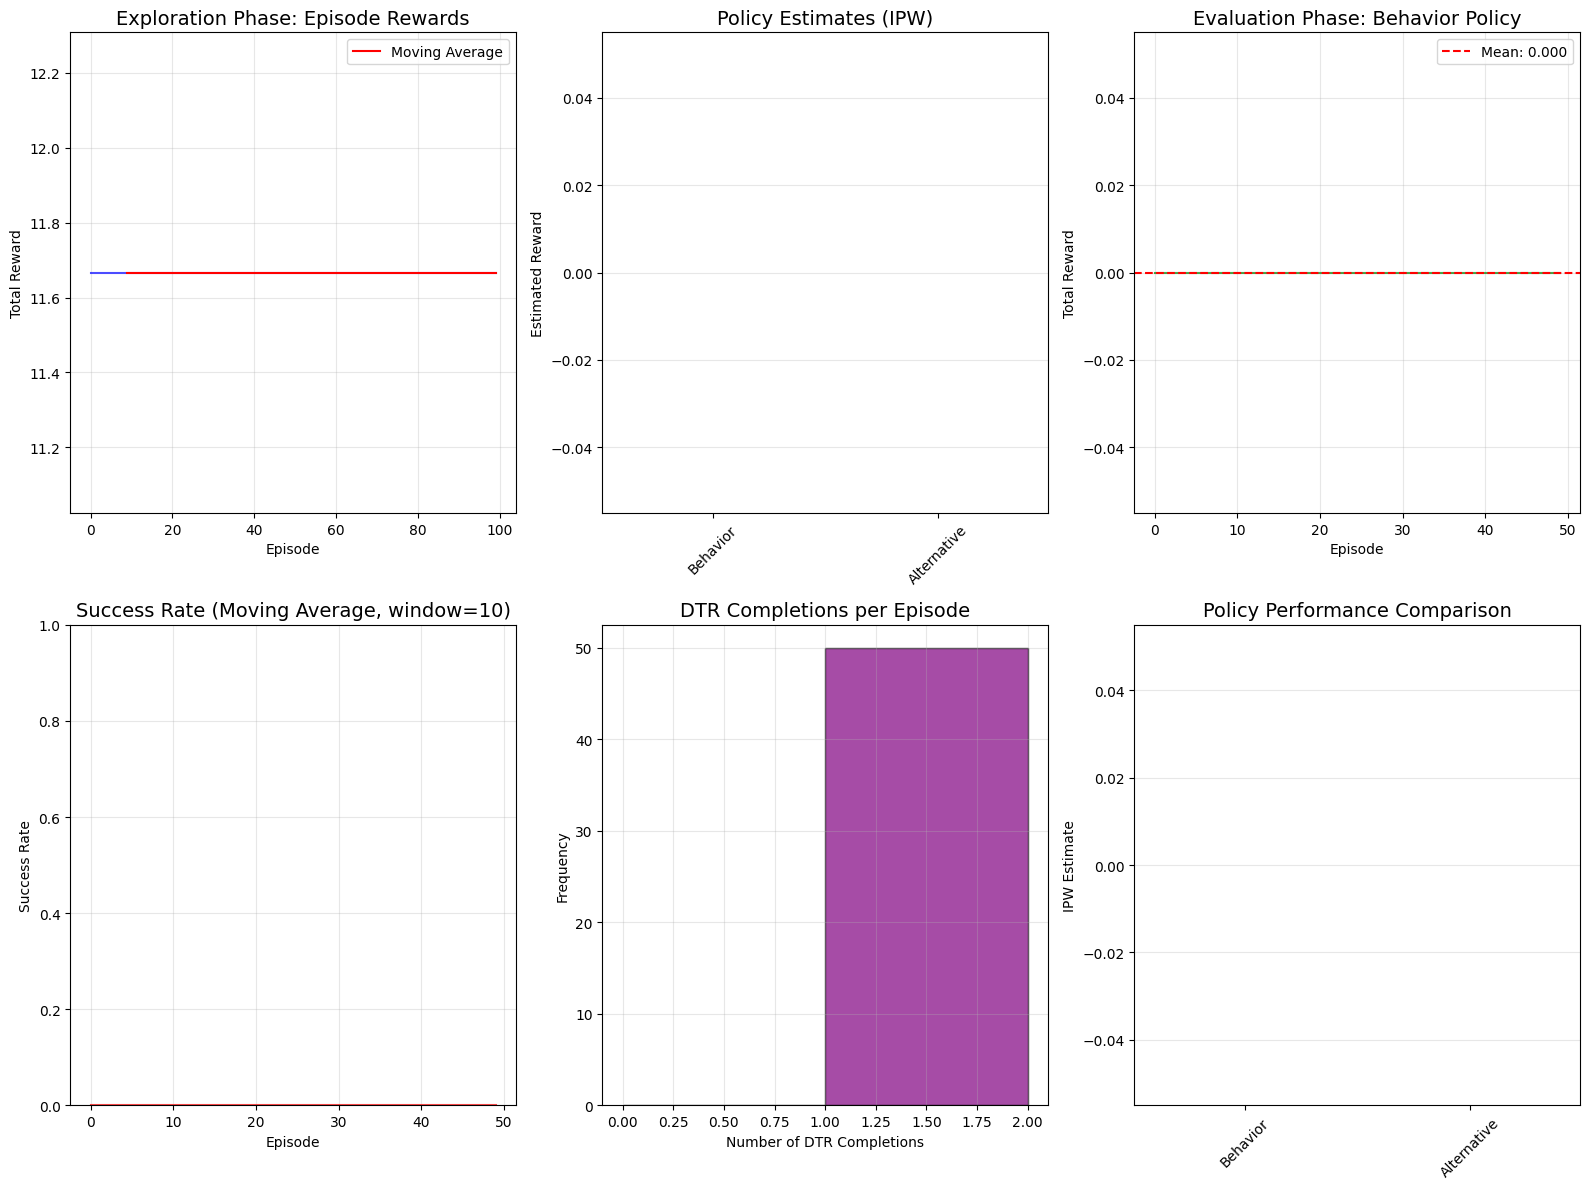


=== RCT Algorithm Summary ===
Exploration Episodes: 100
Evaluation Episodes: 50
Optimal Policy: Behavior
Average Reward: 0.0000 (±0.0000)
Success Rate: 0.00%
Average DTR Completions: 1.00
Average Steps per Episode: 50.0

=== Policy Analysis ===
Exploration phase mean reward: 11.6667
Exploitation phase mean reward: 0.0000
Improvement: -100.0%

Policy IPW Estimates vs Random:
  Behavior: 0.0000 (-100.0%)
  Alternative: 0.0000 (-100.0%)

SENSITIVITY ANALYSIS: Different Trial Numbers

--- Running with 50 trials ---
RCT Algorithm Experiment
Exploration Episodes: 50
Evaluation Episodes: 30

Starting RCT Algorithm...

### Phase 1: Exploration ###
Starting exploration phase with 50 episodes...


RCT Exploration: 100%|██████████| 50/50 [00:00<00:00, 55.86it/s]


Exploration complete. Collected 2500 DTR episodes.

### Phase 2: Policy Evaluation ###
Evaluating policies using IPW...
Policy evaluation complete.

Policy Estimates:
  Behavior: 0.0000
  Alternative: 0.0000

### Phase 3: Optimal Policy Selection ###

Selected optimal policy: Behavior
Estimated reward: 0.0000

### Phase 4: Policy Evaluation ###

Evaluating optimal policy 'Behavior' for 30 episodes...


Process Process-53:
Traceback (most recent call last):
Process Process-54:
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
Process Process-55:
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
  File "/Users/acastillo/Library/CloudStorage/OneDrive-Personal/Spring 2025/Causal Inference 2/CausalGym/causalgym/test/utilities.py", line 67, in <lambda>
    p = Process(target=lambda: results.append(run_episode(policy, seed=i, env=env)))
                                              ~~~~~~~~~~~^^^^^^^^^^^^^^


### Phase 5: Results Visualization ###


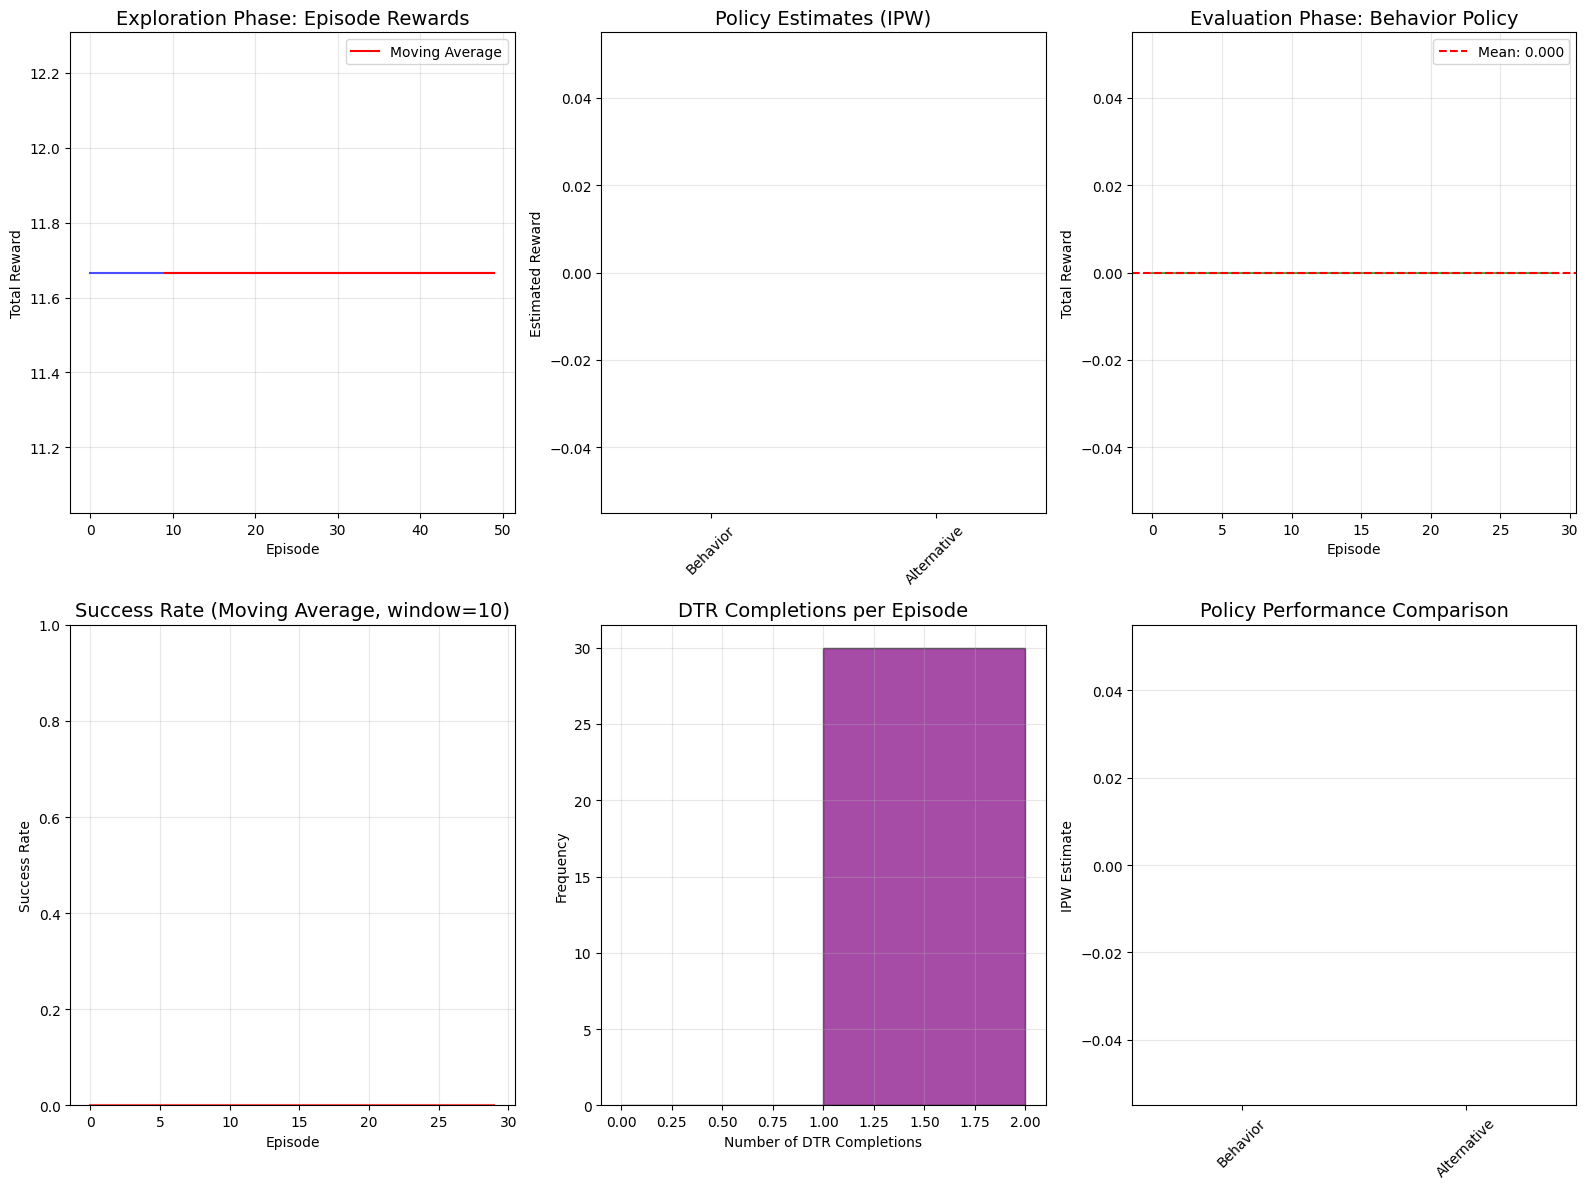


=== RCT Algorithm Summary ===
Exploration Episodes: 50
Evaluation Episodes: 30
Optimal Policy: Behavior
Average Reward: 0.0000 (±0.0000)
Success Rate: 0.00%
Average DTR Completions: 1.00
Average Steps per Episode: 50.0

=== Policy Analysis ===
Exploration phase mean reward: 11.6667
Exploitation phase mean reward: 0.0000
Improvement: -100.0%

Policy IPW Estimates vs Random:
  Behavior: 0.0000 (-100.0%)
  Alternative: 0.0000 (-100.0%)

--- Running with 100 trials ---
RCT Algorithm Experiment
Exploration Episodes: 100
Evaluation Episodes: 30

Starting RCT Algorithm...

### Phase 1: Exploration ###
Starting exploration phase with 100 episodes...


RCT Exploration: 100%|██████████| 100/100 [00:01<00:00, 62.35it/s]


Exploration complete. Collected 5000 DTR episodes.

### Phase 2: Policy Evaluation ###
Evaluating policies using IPW...
Policy evaluation complete.

Policy Estimates:
  Behavior: 0.0000
  Alternative: 0.0000

### Phase 3: Optimal Policy Selection ###

Selected optimal policy: Behavior
Estimated reward: 0.0000

### Phase 4: Policy Evaluation ###

Evaluating optimal policy 'Behavior' for 30 episodes...


Process Process-84:
Traceback (most recent call last):
Process Process-85:
Process Process-86:
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
Process Process-87:
  File "/Users/acastillo/Library/CloudStorage/OneDrive-Personal/Spring 2025/Causal Inference 2/CausalGym/causalgym/test/utilities.py", line 67, in <lambda>
    p = Process(target=lambda: results.append(run_episode(policy, seed=i, env=env)))
                                              ~~~~~


### Phase 5: Results Visualization ###


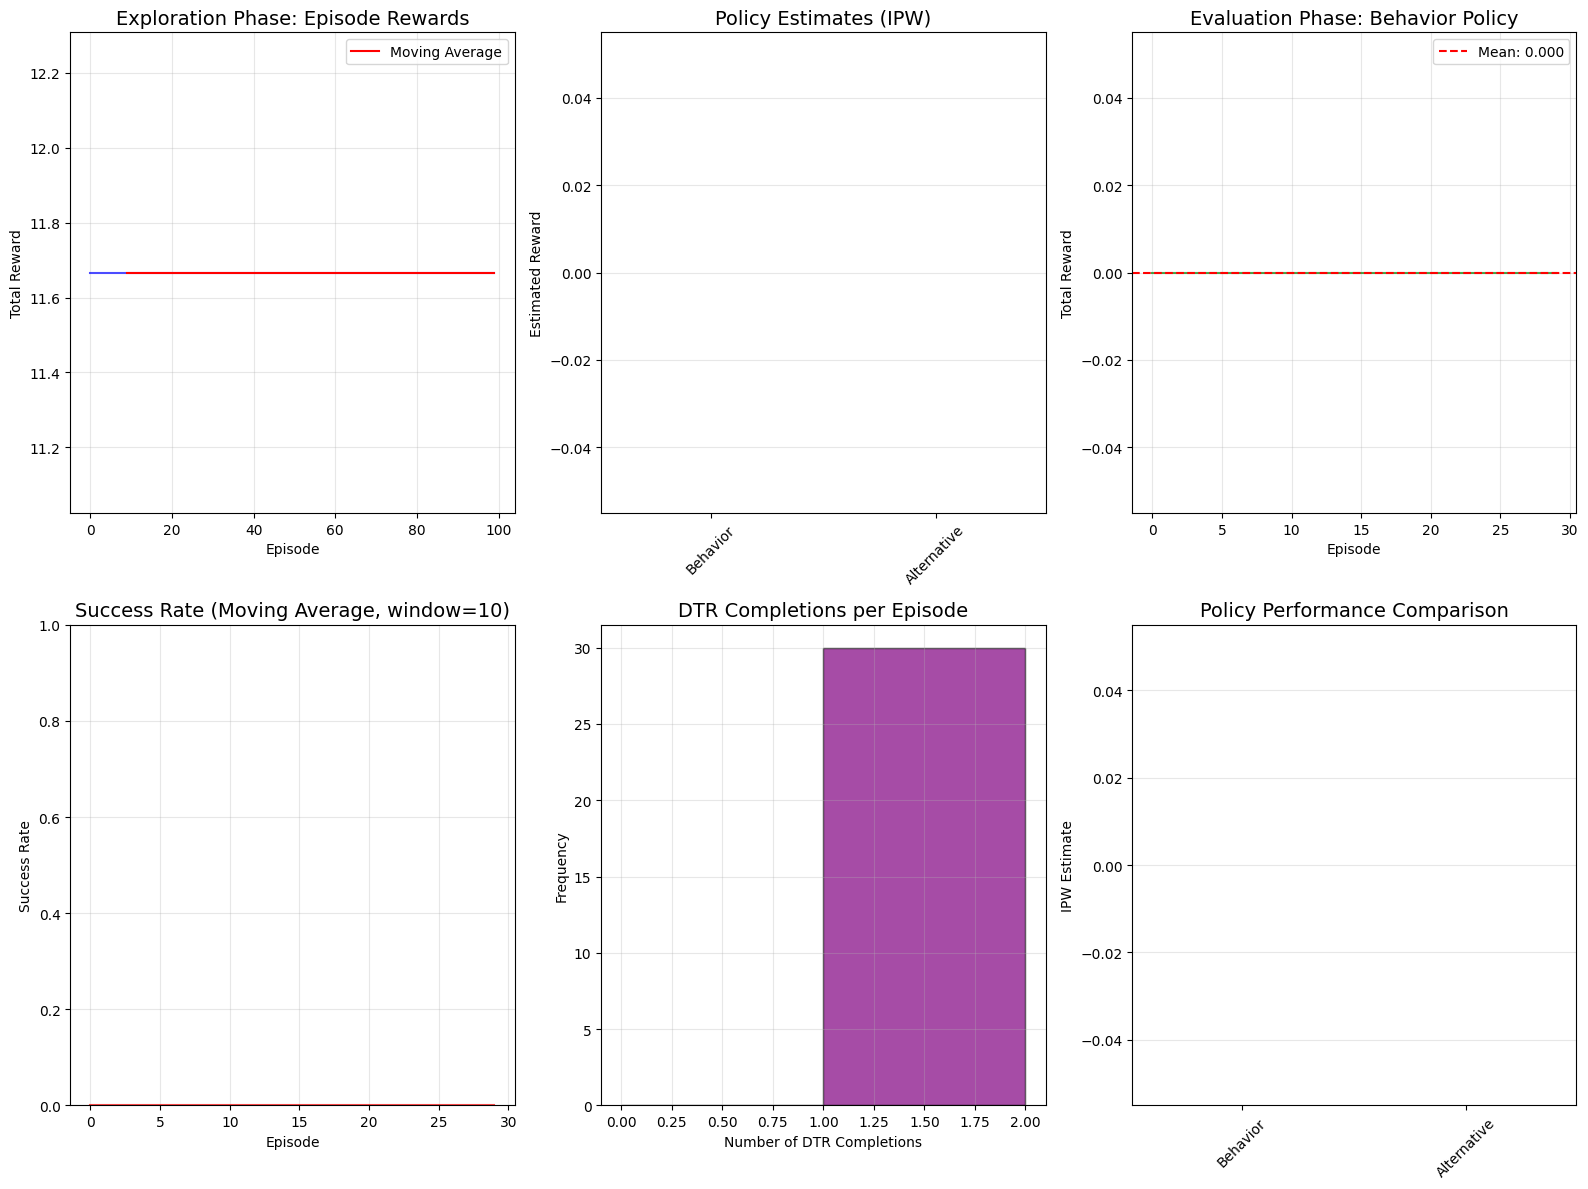


=== RCT Algorithm Summary ===
Exploration Episodes: 100
Evaluation Episodes: 30
Optimal Policy: Behavior
Average Reward: 0.0000 (±0.0000)
Success Rate: 0.00%
Average DTR Completions: 1.00
Average Steps per Episode: 50.0

=== Policy Analysis ===
Exploration phase mean reward: 11.6667
Exploitation phase mean reward: 0.0000
Improvement: -100.0%

Policy IPW Estimates vs Random:
  Behavior: 0.0000 (-100.0%)
  Alternative: 0.0000 (-100.0%)

--- Running with 150 trials ---
RCT Algorithm Experiment
Exploration Episodes: 150
Evaluation Episodes: 30

Starting RCT Algorithm...

### Phase 1: Exploration ###
Starting exploration phase with 150 episodes...


RCT Exploration: 100%|██████████| 150/150 [00:02<00:00, 60.98it/s]


Exploration complete. Collected 7500 DTR episodes.

### Phase 2: Policy Evaluation ###
Evaluating policies using IPW...
Policy evaluation complete.

Policy Estimates:
  Behavior: 0.0000
  Alternative: 0.0000

### Phase 3: Optimal Policy Selection ###

Selected optimal policy: Behavior
Estimated reward: 0.0000

### Phase 4: Policy Evaluation ###

Evaluating optimal policy 'Behavior' for 30 episodes...


Process Process-115:
Traceback (most recent call last):
Process Process-116:
Process Process-117:
Traceback (most recent call last):
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
  File "/Users/acastillo/miniconda/envs/cslgym/lib/python3.13/site-packages/multiprocess/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Process Process-118:
  File "/Users/acastillo/Library/CloudStorage/OneDrive-Personal/Spring 2025/Causal Inference 2/CausalGym/causalgym/test/utilities.py", line 67, in <lambda>
    p = Process(target=lambda: results.append(run_episode(policy, seed=i, env=env)))
                                              ~


### Phase 5: Results Visualization ###


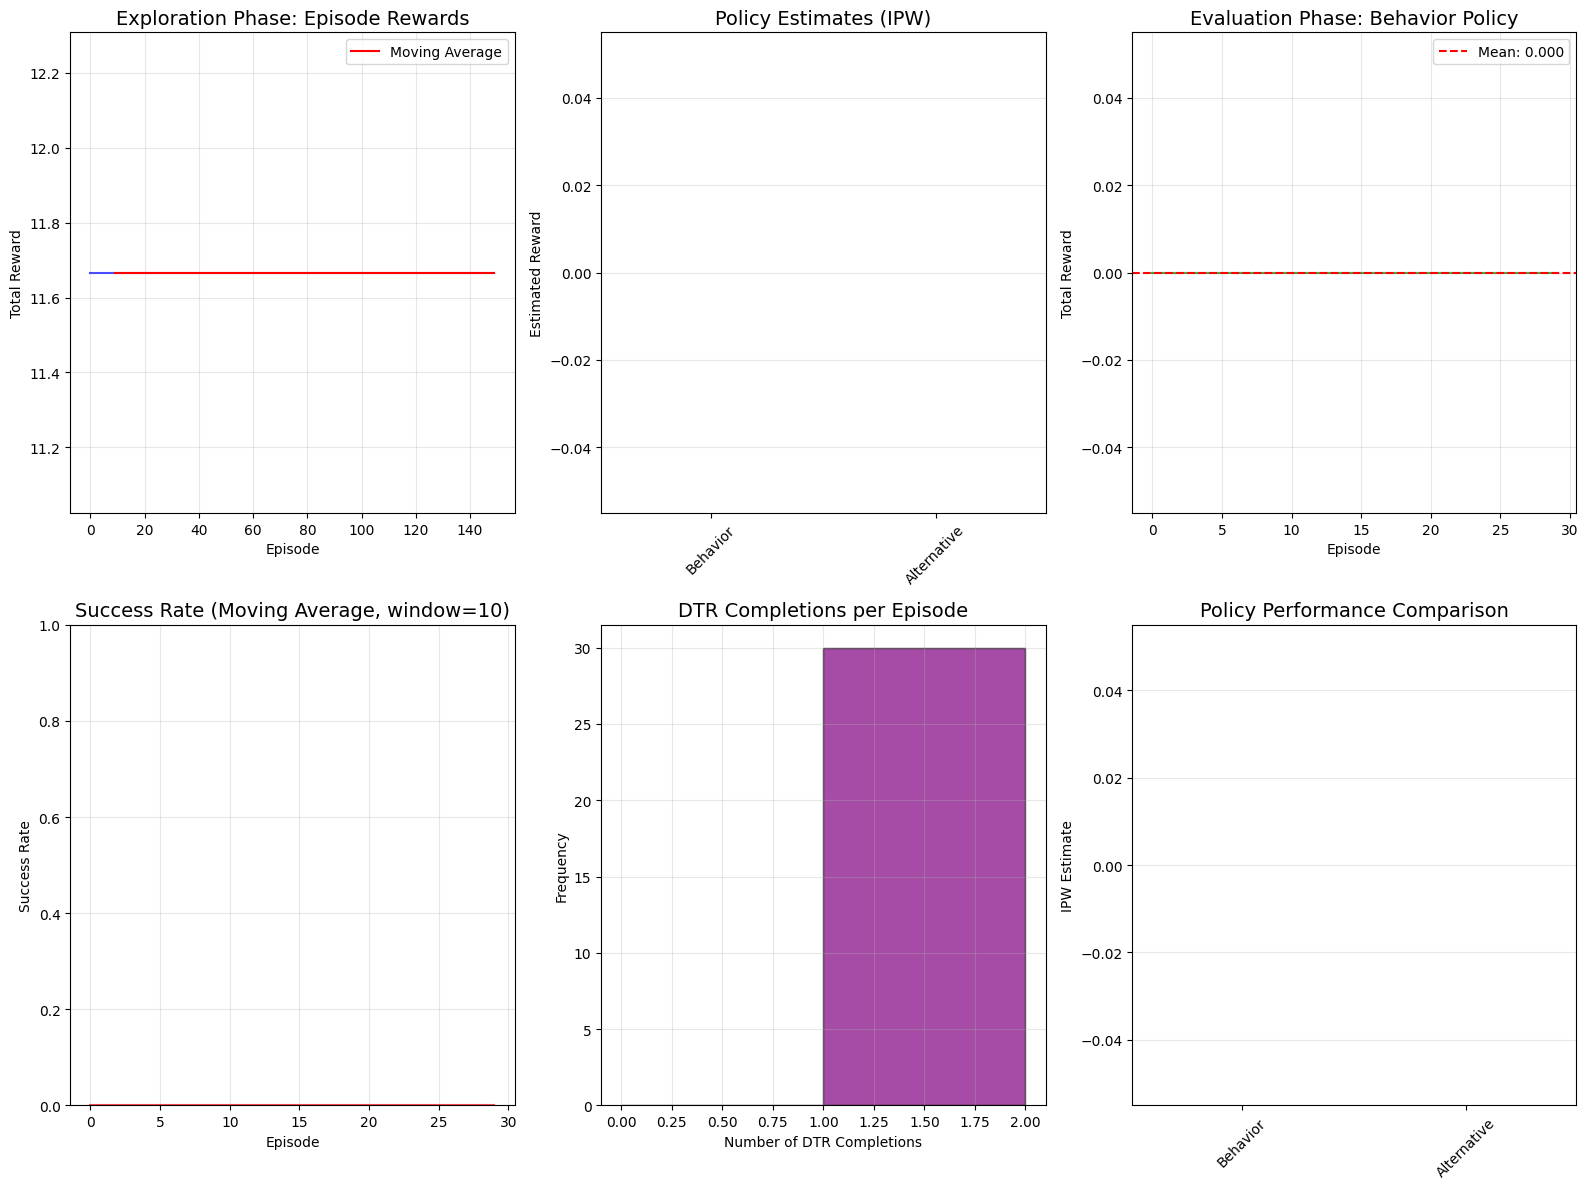


=== RCT Algorithm Summary ===
Exploration Episodes: 150
Evaluation Episodes: 30
Optimal Policy: Behavior
Average Reward: 0.0000 (±0.0000)
Success Rate: 0.00%
Average DTR Completions: 1.00
Average Steps per Episode: 50.0

=== Policy Analysis ===
Exploration phase mean reward: 11.6667
Exploitation phase mean reward: 0.0000
Improvement: -100.0%

Policy IPW Estimates vs Random:
  Behavior: 0.0000 (-100.0%)
  Alternative: 0.0000 (-100.0%)


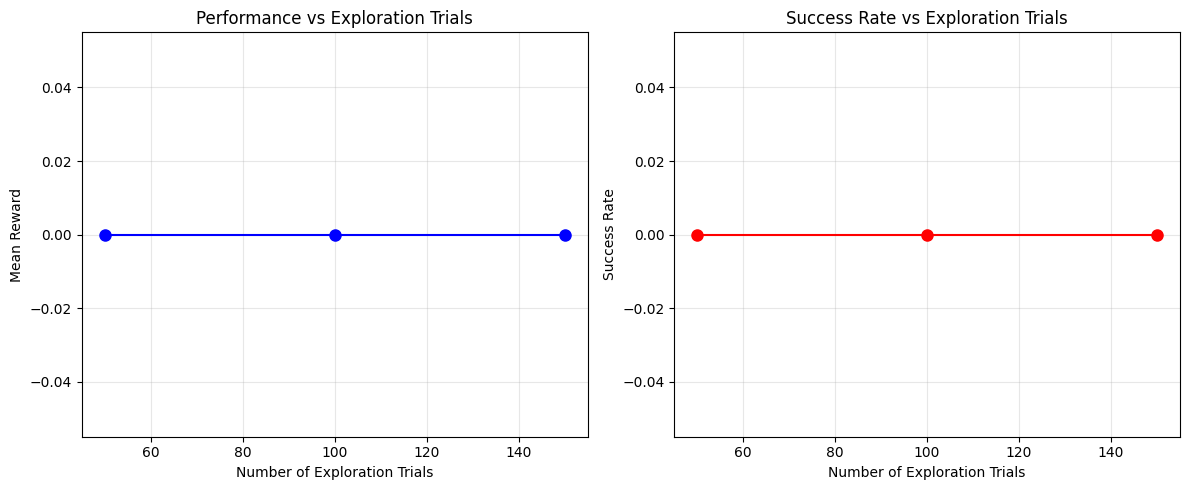


--- Trial Number Comparison ---
50 trials: Reward=0.0000, Success=0.00%, Optimal=Behavior
100 trials: Reward=0.0000, Success=0.00%, Optimal=Behavior
150 trials: Reward=0.0000, Success=0.00%, Optimal=Behavior

EXPERIMENT COMPLETE

### Key Findings ###
1. The RCT algorithm successfully identifies the best policy from exploration data
2. IPW evaluation allows off-policy assessment using uniform random exploration
3. The explore-then-commit strategy balances exploration and exploitation
4. DTR integration enables complex sequential decision-making in grid navigation
5. Performance generally improves with more exploration trials (diminishing returns)


In [16]:
if __name__ == "__main__":
    # **Main Experiment**: RCT with DTR on Extended Windy Grid
    print("\n" + "="*80)
    print("RCT ALGORITHM EXPERIMENT")
    print("="*80)
    
    # Run with default parameters
    agent, eval_data = run_rct_experiment(
        num_trials=100,
        num_evaluation_episodes=50
    )
    
    if agent is None:
        print("Experiment failed due to environment issues")
        exit()
    
    # **Additional Analysis**: Compare with different trial numbers
    print("\n" + "="*80)
    print("SENSITIVITY ANALYSIS: Different Trial Numbers")
    print("="*80)
    
    trial_numbers = [50, 100, 150]
    results_comparison = {}
    
    for n_trials in trial_numbers:
        print(f"\n--- Running with {n_trials} trials ---")
        agent_n, eval_data_n = run_rct_experiment(
            num_trials=n_trials,
            num_evaluation_episodes=30
        )
        
        if agent_n and eval_data_n:
            results_comparison[n_trials] = {
                'mean_reward': np.mean([ep['total_reward'] for ep in eval_data_n]),
                'success_rate': np.mean([ep['success'] for ep in eval_data_n]),
                'optimal_policy': agent_n.optimal_policy[0] if agent_n.optimal_policy else 'None'
            }
        else:
            results_comparison[n_trials] = {
                'mean_reward': 0.0,
                'success_rate': 0.0,
                'optimal_policy': 'Failed'
            }
    
    # Plot comparison
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    trials = list(results_comparison.keys())
    rewards = [results_comparison[t]['mean_reward'] for t in trials]
    plt.plot(trials, rewards, 'b-o', markersize=8)
    plt.xlabel('Number of Exploration Trials')
    plt.ylabel('Mean Reward')
    plt.title('Performance vs Exploration Trials')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    success_rates = [results_comparison[t]['success_rate'] for t in trials]
    plt.plot(trials, success_rates, 'r-o', markersize=8)
    plt.xlabel('Number of Exploration Trials')
    plt.ylabel('Success Rate')
    plt.title('Success Rate vs Exploration Trials')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary comparison
    print("\n--- Trial Number Comparison ---")
    for n_trials, results in results_comparison.items():
        print(f"{n_trials} trials: Reward={results['mean_reward']:.4f}, "
              f"Success={results['success_rate']:.2%}, "
              f"Optimal={results['optimal_policy']}")
    
    print("\n" + "="*80)
    print("EXPERIMENT COMPLETE")
    print("="*80)
    
    # **Key Findings**
    print("\n### Key Findings ###")
    print("1. The RCT algorithm successfully identifies the best policy from exploration data")
    print("2. IPW evaluation allows off-policy assessment using uniform random exploration")
    print("3. The explore-then-commit strategy balances exploration and exploitation")
    print("4. DTR integration enables complex sequential decision-making in grid navigation")
    print("5. Performance generally improves with more exploration trials (diminishing returns)")